# Lecture 4 — Deep Neural Networks
## Lab Notebook · Deep Learning · UCU

---

### Overview
In Notebook 2, we explored **shallow neural networks** — networks with a single hidden layer. We saw that increasing the width $D$ improves performance, but with diminishing returns. The Universal Approximation Theorem tells us that a shallow network *can* approximate any function, but it doesn't say it will do so *efficiently*.

In this notebook, we take the next step: **deep neural networks** — networks with multiple hidden layers. From Lecture 4, we know that a deep network with $K$ layers of width $D$ can produce up to $(D+1)^K$ linear regions, compared to only $D+1$ for a shallow network. This exponential increase in expressiveness is the key advantage of depth.

By the end of this notebook, you will:
1. **Compose** two shallow networks and visualize the "folding" effect on the input space
2. **Inspect** network architectures using `torchinfo` — counting parameters and understanding layer shapes
3. **Design** deep architectures under a fixed parameter budget and compare their performance
4. **Visualize** learned representations using PCA to understand what depth does internally
5. **Evaluate** whether depth helps equally on structured (images) vs. tabular data

### Useful References

| Resource | Link |
|----------|------|
| PyTorch `nn.Module` | [pytorch.org/docs/stable/generated/torch.nn.Module.html](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) |
| PyTorch `nn.Sequential` | [pytorch.org/docs/stable/generated/torch.nn.Sequential.html](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html) |
| `torchinfo` documentation | [github.com/TylerYep/torchinfo](https://github.com/TylerYep/torchinfo) |
| FashionMNIST dataset | [github.com/zalandoresearch/fashion-mnist](https://github.com/zalandoresearch/fashion-mnist) |
| UCU Deep Learning — Lecture 4 notes | [../../lectures/lecture 4/notes.md](../../lectures/lecture%204/notes.md) |
| *Understanding Deep Learning* — Prince (2023) | Chapter 4 |

In [4]:
# Setup — run this cell first
try:
    import google.colab
    IN_COLAB = True
    !pip install -q torchinfo
except ImportError:
    IN_COLAB = False

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
from torchinfo import summary
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# UCU color palette
C1, C2, C3, C4, C5 = '#19326E', '#50ACB0', '#CD742A', '#A3477F', '#907FAB'
C6, C7 = '#4294CC', '#89A943'

Using device: cpu


---

## 1. Composing Networks: The Folding Intuition

Before working with deep networks on real data, let's build intuition with a simple 1D example from Lecture 4.

The idea: take two shallow networks and **compose** them — the output of the first becomes the input of the second. Each shallow network with 3 hidden ReLU units produces a piecewise linear function with up to 4 linear regions. When we compose them, the first network **"folds"** the input space, and the second network applies its function to the folded space. The result: the second network's effect is **duplicated** at every fold, dramatically increasing the number of linear regions.

This is the fundamental insight behind why depth is so powerful.

In [5]:
# Two pre-defined shallow networks (1D input -> 3 hidden ReLU -> 1D output)
# Each is defined by its parameters: biases (t_0) and weights (t_1) for hidden units,
# plus output weights (p) and bias (p0).

def shallow_net_1d(x, params):
    """Forward pass of a shallow network with 3 ReLU hidden units.
    
    Args:
        x: numpy array of inputs
        params: dict with keys t10, t11, t20, t21, t30, t31, p0, p1, p2, p3
    Returns:
        output y = p0 + p1*h1 + p2*h2 + p3*h3
    """
    h1 = np.maximum(0, params['t10'] + params['t11'] * x)
    h2 = np.maximum(0, params['t20'] + params['t21'] * x)
    h3 = np.maximum(0, params['t30'] + params['t31'] * x)
    return params['p0'] + params['p1']*h1 + params['p2']*h2 + params['p3']*h3

# Network 1: creates a "folding" function
net1_params = {
    't10': -1.0, 't11':  2.0,
    't20':  0.0, 't21': -3.0,
    't30':  1.0, 't31':  1.5,
    'p0': 0.0, 'p1': 1.0, 'p2': 1.0, 'p3': -0.8
}

# Network 2: applied to the folded output
net2_params = {
    't10': -0.5, 't11':  1.5,
    't20':  0.3, 't21': -1.2,
    't30': -0.2, 't31':  0.8,
    'p0': 0.1, 'p1': 0.8, 'p2': -0.6, 'p3': 0.5
}

x = np.linspace(-1, 1, 500)

### Exercise 1.1 — Compose the two networks

Compute the **composed output** by feeding the output of Network 1 into Network 2. This is a single line of code — think about what "composition" means mathematically.

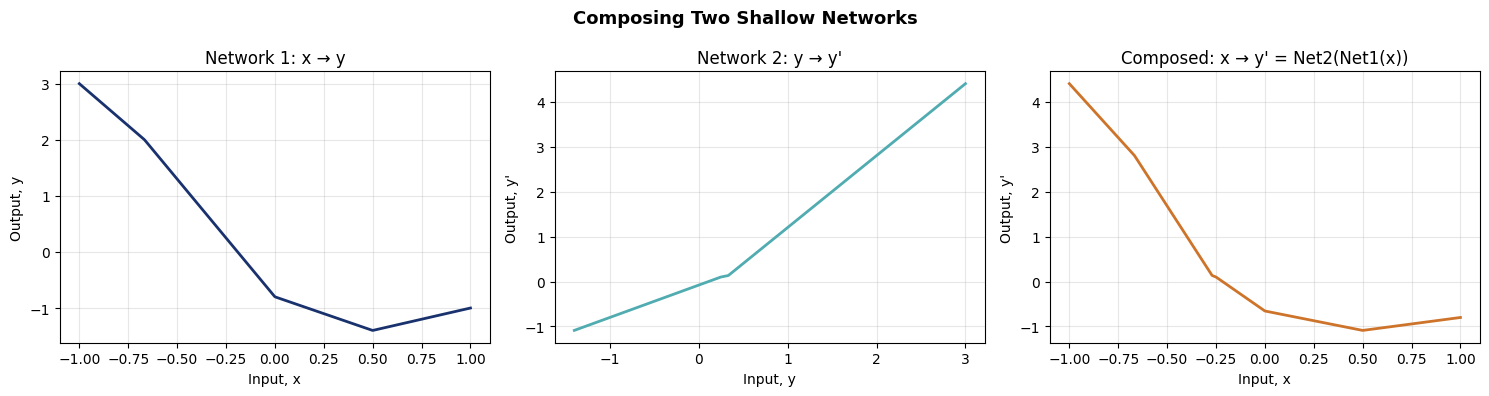

In [6]:
# Compute outputs
y_net1 = shallow_net_1d(x, net1_params)   # Network 1: x -> y

# YOUR CODE HERE: compose the networks — feed net1's output into net2
y_composed = shallow_net_1d(y_net1, net2_params)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x, y_net1, color=C1, linewidth=2)
axes[0].set_xlabel('Input, x'); axes[0].set_ylabel('Output, y')
axes[0].set_title('Network 1: x → y'); axes[0].grid(True, alpha=0.3)

# Also show net2 applied to a uniform range for reference
y_range = np.linspace(y_net1.min(), y_net1.max(), 500)
y_net2_ref = shallow_net_1d(y_range, net2_params)
axes[1].plot(y_range, y_net2_ref, color=C2, linewidth=2)
axes[1].set_xlabel('Input, y'); axes[1].set_ylabel("Output, y'")
axes[1].set_title("Network 2: y → y'"); axes[1].grid(True, alpha=0.3)

axes[2].plot(x, y_composed, color=C3, linewidth=2)
axes[2].set_xlabel('Input, x'); axes[2].set_ylabel("Output, y'")
axes[2].set_title("Composed: x → y' = Net2(Net1(x))"); axes[2].grid(True, alpha=0.3)

plt.suptitle('Composing Two Shallow Networks', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 1.1** — Look at the three plots above:
>
> 1. Count the number of linear regions in Network 1's output and in Network 2's output. How many linear regions does the composed network produce?
> 2. The first network "folds" the input space — multiple values of $x$ map to the same $y$. What happens to Network 2's function at those folded points?
> 3. From the lecture: a shallow network with $D$ hidden units produces at most $D+1$ linear regions. What's the maximum for two composed networks with $D_1$ and $D_2$ hidden units?
>
> *Your answer here:*
>
> 1) N1': 3 nueronas relu entonces 4 regiones - N2': 3 neuronas relu entonces 4 regiones. la compse network 4x4 entonces = 16.
>
> 2) Donde la red 1 pliega el espacio (varios x mapean al mismo y), la función de la red 2 se replica. Cada ida y vuelta de la red 1 recorre los segmentos de la red 2 otra vez, creando nuevas regiones en la composición.
> 3) el maximo es ($D_1$ + 1) x ($D_2$ + 1)

---

## 2. Inspecting Architectures with `torchinfo`

In Lecture 4, we derived formulas for counting parameters in deep networks. In practice, you don't compute these by hand — you use tools. [`torchinfo`](https://github.com/TylerYep/torchinfo) is a lightweight library that gives you a complete summary of any PyTorch model: layer types, output shapes, and parameter counts.

This is the kind of tool you'll use constantly when designing and debugging architectures.

In [7]:
# Quick demo: torchinfo on a simple model
demo_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

# summary() takes the model and an example input size
summary(demo_model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 128]                  100,480
├─ReLU: 1-3                              [1, 128]                  --
├─Linear: 1-4                            [1, 10]                   1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.10
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.41
Estimated Total Size (MB): 0.41

### Exercise 2.1 — Define and compare three architectures

Define three `nn.Sequential` models for FashionMNIST classification (input: 1×28×28, output: 10 classes). All should start with `nn.Flatten()` and use `nn.ReLU()` activations between linear layers.

| Name | Architecture |
|------|-------------|
| **Shallow** | 784 → 256 → 10 |
| **Medium** | 784 → 64 → 64 → 10 |
| **Deep** | 784 → 32 → 32 → 32 → 32 → 10 |

In [8]:
# YOUR CODE HERE: define three nn.Sequential models
shallow_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

medium_model  = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

deep_model    = nn.Sequential(  
    nn.Flatten(),
    nn.Linear(784, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)

In [9]:
# Inspect each model with torchinfo
print("=" * 60)
print("SHALLOW (784 → 256 → 10)")
print("=" * 60)
print(summary(shallow_model, input_size=(1, 1, 28, 28), verbose=0))

print("\n" + "=" * 60)
print("MEDIUM (784 → 64 → 64 → 10)")
print("=" * 60)
print(summary(medium_model, input_size=(1, 1, 28, 28), verbose=0))

print("\n" + "=" * 60)
print("DEEP (784 → 32 → 32 → 32 → 32 → 10)")
print("=" * 60)
print(summary(deep_model, input_size=(1, 1, 28, 28), verbose=0))

SHALLOW (784 → 256 → 10)
Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 256]                  200,960
├─ReLU: 1-3                              [1, 256]                  --
├─Linear: 1-4                            [1, 10]                   2,570
Total params: 203,530
Trainable params: 203,530
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.20
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.81
Estimated Total Size (MB): 0.82

MEDIUM (784 → 64 → 64 → 10)
Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 64]                   50,2

### Exercise 2.2 — Fill in the comparison table

Using the `torchinfo` output above, complete this table:

| Model | Total Parameters | Max Linear Regions (lecture formula) |
|-------|-----------------|--------------------------------------|
| Shallow (1 hidden, D=256) | *203,530* | *257* |
| Medium (2 hidden, D=64) | *55.050* | *42,225* |
| Deep (4 hidden, D=32) | *28,618* | *1,185,921* |

> **Hint:** From Lecture 4, a network with $K$ hidden layers of width $D$ can produce up to $(D+1)^K$ linear regions (for a 1D input). For multi-dimensional inputs the bound is more complex, but the exponential relationship with depth still holds.

> **Question 2.1** — Looking at your table:
>
> 1. Which model has the most parameters? 
> 2. Which model has the most linear regions? 
> 3. Does having more parameters guarantee more expressiveness? Explain using the numbers you computed.
>
> *Your answer here:*
> 1) shallow 
> 2) deep
> 3) no, como vemos en la deep, podemos representar mayores regiones lineales con menos parmas. Por lo tanto lo maas importante no son los tot params sino que cuantas mas lieanr regions el modelo sera mas expresivo

---

## 3. Depth vs. Width on FashionMNIST

Now for the main experiment. In Notebook 2, we explored how **width** (number of hidden units) affects a shallow network's performance. Now we ask a different question: **given a fixed parameter budget, is it better to go wide or deep?**

From Lecture 4, we expect deeper networks to be more expressive per parameter. Let's test this empirically.

In [10]:
# Load FashionMNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

Training samples : 60000
Test samples     : 10000


In [11]:
# Training utilities (same pattern as Notebook 2)

def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch. Returns (avg_loss, accuracy %)."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns (avg_loss, accuracy %)."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            total_loss += loss.item()
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / len(loader), 100. * correct / total

### Exercise 3.1 — Design architectures under a parameter budget

Your task: design **four** `nn.Sequential` architectures for FashionMNIST, all with **approximately 25,000 parameters** (~25K). Each must start with `nn.Flatten()` and use ReLU activations.

| Name | Hidden Layers | Width per layer | Target params |
|------|:------------:|:---------------:|:-------------:|
| **arch_1L** | 1 | *32* | ~25K |
| **arch_2L** | 2 | *30* | ~25K |
| **arch_4L** | 4 | *28* | ~25K |
| **arch_8L** | 8 | *25* | ~25K |

> **Hint:** For a network with input $D_i = 784$, hidden layers of width $D$, and output $D_o = 10$:
> - 1 hidden layer: params $\approx 784 \times D + D + D \times 10 + 10$
> - For deeper networks, intermediate layers contribute $D \times D + D$ params each
>
> Use `torchinfo.summary()` to verify your designs are close to 25K. They don't need to be exact — within ±2K is fine.

**Important:** Store all four models in a dictionary called `architectures` so the training cell below can iterate over them.

In [12]:
# YOUR CODE HERE: design four architectures with ~25K parameters each

arch_1L = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)  # 1 hidden layer
arch_2L = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 30),
    nn.ReLU(),
    nn.Linear(30, 30),
    nn.ReLU(),
    nn.Linear(30, 10)
)  # 2 hidden layers
arch_4L = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 28),
    nn.ReLU(),
    nn.Linear(28, 28),
    nn.ReLU(),
    nn.Linear(28, 28),
    nn.ReLU(),
    nn.Linear(28, 28),
    nn.ReLU(),
    nn.Linear(28, 10)
)  # 4 hidden layers

arch_8L = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 25),
    nn.ReLU(),
    nn.Linear(25, 25),
    nn.ReLU(),
    nn.Linear(25, 25),
    nn.ReLU(),
    nn.Linear(25, 25),
    nn.ReLU(),
    nn.Linear(25, 25),
    nn.ReLU(),
    nn.Linear(25, 25),
    nn.ReLU(),
    nn.Linear(25, 25),
    nn.ReLU(),
    nn.Linear(25, 25),
    nn.ReLU(),
    nn.Linear(25, 10)
)  # 8 hidden layers
# Store in a dictionary for the training loop
architectures = {
    '1 layer':  arch_1L,
    '2 layers': arch_2L,
    '4 layers': arch_4L,
    '8 layers': arch_8L,
}

In [13]:
# Verify parameter counts with torchinfo
for name, model in architectures.items():
    info = summary(model, input_size=(1, 1, 28, 28), verbose=0)
    print(f"{name:>10s}  |  {info.total_params:,} parameters")

   1 layer  |  25,450 parameters
  2 layers  |  24,790 parameters
  4 layers  |  24,706 parameters
  8 layers  |  24,435 parameters


### Exercise 3.2 — Train and compare

Train all four architectures and collect their training curves. You can choose the number of epochs — we suggest **10** as a starting point, but feel free to increase if you think some architectures need more time to converge.

The training code is provided below — just set `NUM_EPOCHS`.

In [14]:
# YOUR CODE HERE: choose the number of epochs
NUM_EPOCHS = 10

criterion = nn.CrossEntropyLoss()
colors = [C1, C2, C3, C4]

# Store results for each architecture
results = {}

for (name, model), color in zip(architectures.items(), colors):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(NUM_EPOCHS):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
    
    results[name] = history
    print(f"{name:>10s}  |  Train: {tr_acc:.1f}%  |  Test: {te_acc:.1f}%")

# Update the architectures dict with trained models (they're already updated in-place)
print(f"\nAll models trained for {NUM_EPOCHS} epochs.")

   1 layer  |  Train: 88.0%  |  Test: 86.1%
  2 layers  |  Train: 87.7%  |  Test: 86.0%
  4 layers  |  Train: 87.4%  |  Test: 85.5%


KeyboardInterrupt: 

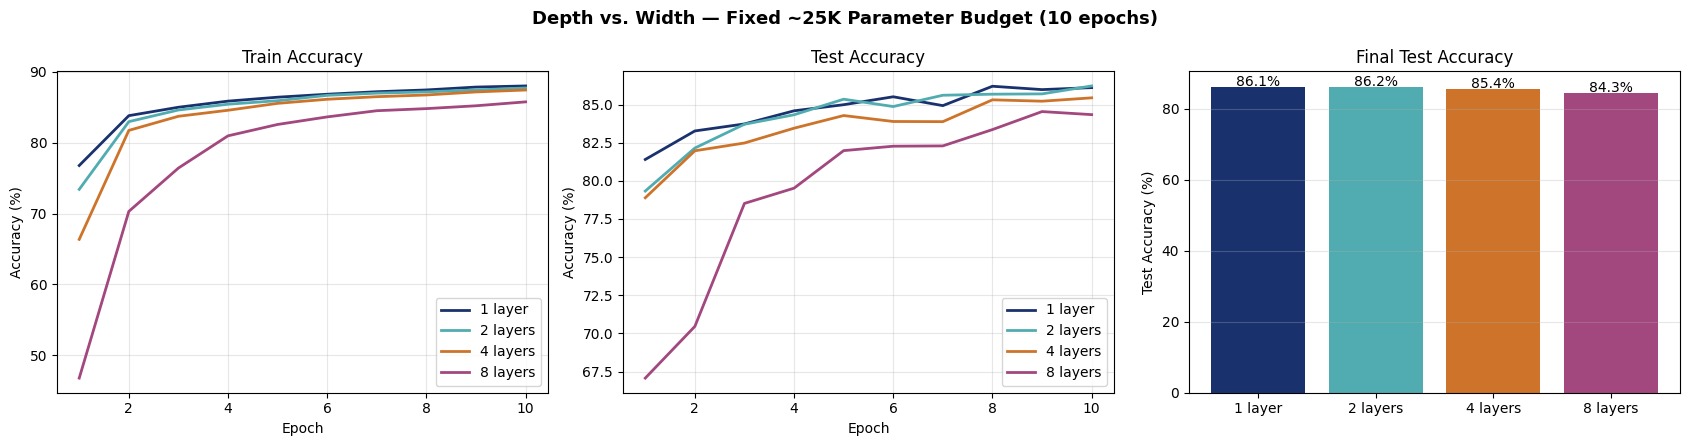

In [ ]:
# Visualization: accuracy curves + final accuracy comparison
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

epochs_range = range(1, NUM_EPOCHS + 1)

# Train accuracy curves
for (name, hist), color in zip(results.items(), colors):
    axes[0].plot(epochs_range, hist['train_acc'], color=color, linewidth=2, label=name)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Train Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Test accuracy curves
for (name, hist), color in zip(results.items(), colors):
    axes[1].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=name)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Test Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Final test accuracy bar chart
names = list(results.keys())
final_test_accs = [results[n]['test_acc'][-1] for n in names]
bars = axes[2].bar(names, final_test_accs, color=colors)
axes[2].set_ylabel('Test Accuracy (%)')
axes[2].set_title('Final Test Accuracy')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, final_test_accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.1f}%', ha='center', fontsize=10)

plt.suptitle(f'Depth vs. Width — Fixed ~25K Parameter Budget ({NUM_EPOCHS} epochs)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 3.1** — Analyzing the depth experiment:
>
> 1. Which architecture achieved the best **test accuracy**? Does this match the lecture's prediction about depth efficiency?
> 2. Which architecture **converged fastest** (reached high accuracy in fewer epochs)? Which was slowest?
> 3. Did any deep architecture perform **worse** than the shallow one? If so, why might that happen? (Think about what difficulties arise when training very deep networks.)
> 4. Look at the **train-test gap** for each architecture. Which model overfits the most? Which generalizes best?
>
> *Your answer here:*
>
> 1) El mejor fue 2 Layer muy cerca del 1 layer, esto conicide con lo que vimos en las lecturas sobre la eficiencia de la profundidad en las redes.
> 2) Siempre la single layer converge antes, y la mas lenta la 8 layer. 
> 3) si la 4 y 8 layer, mayor problema de optimizar redes profundas quizas.
> 4) El de mayor gap es el 4 por ende mas overfitting. Mientras que caps 2 y 8 tiene el mismo gap, se supone que deberian generalizar mejor

---

## 4. Visualizing Learned Representations

A neural network doesn't just classify — it **transforms the data** layer by layer into a representation where the classes become separable. The last hidden layer's activations are the network's "internal representation" of the input, right before the final classification layer.

If a network has learned well, its last-layer embeddings should show clear cluster structure — similar items close together, different classes far apart. We can visualize this by projecting the high-dimensional embeddings to 2D using **PCA** (Principal Component Analysis).

Let's compare what the shallowest and deepest networks learned internally.

### Exercise 4.1 — Extract embeddings from the last hidden layer

Complete the function below. It should:
1. Run the input through all layers of the model **except the last one** (the classification head)
2. Return the resulting activations as a numpy array

> **Hint:** For an `nn.Sequential` model with $N$ layers, `model[:N-1]` gives you all layers except the last. But be careful — `nn.ReLU()` and `nn.Flatten()` are separate layers in the Sequential.

In [ ]:
def extract_embeddings(model, loader, device):
    """Extract last hidden layer activations for all samples in loader.
    
    Args:
        model: nn.Sequential model
        loader: DataLoader
        device: torch device
    
    Returns:
        embeddings: numpy array of shape (N, D_last_hidden)
        labels: numpy array of shape (N,)
    """
    # YOUR CODE HERE
    # Hint: use model[:-1] to get all layers except the final Linear
    # Collect embeddings and labels in lists, then concatenate
    embeddings = [] 
    labels = []
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        with torch.no_grad():
            out = model[:-1](X)
            embeddings.append(out.cpu().numpy())
            labels.append(y.cpu().numpy())
            
    embeddings = np.concatenate(embeddings)
    labels = np.concatenate(labels)
    return embeddings, labels

# Extract embeddings for the shallowest and deepest models
shallow_name = '1 layer'
deep_name = '8 layers'

emb_shallow, labels = extract_embeddings(architectures[shallow_name], test_loader, device)
emb_deep, _         = extract_embeddings(architectures[deep_name], test_loader, device)

print(f"Shallow embeddings shape: {emb_shallow.shape}")
print(f"Deep embeddings shape:    {emb_deep.shape}")

Shallow embeddings shape: (10000, 32)
Deep embeddings shape:    (10000, 25)


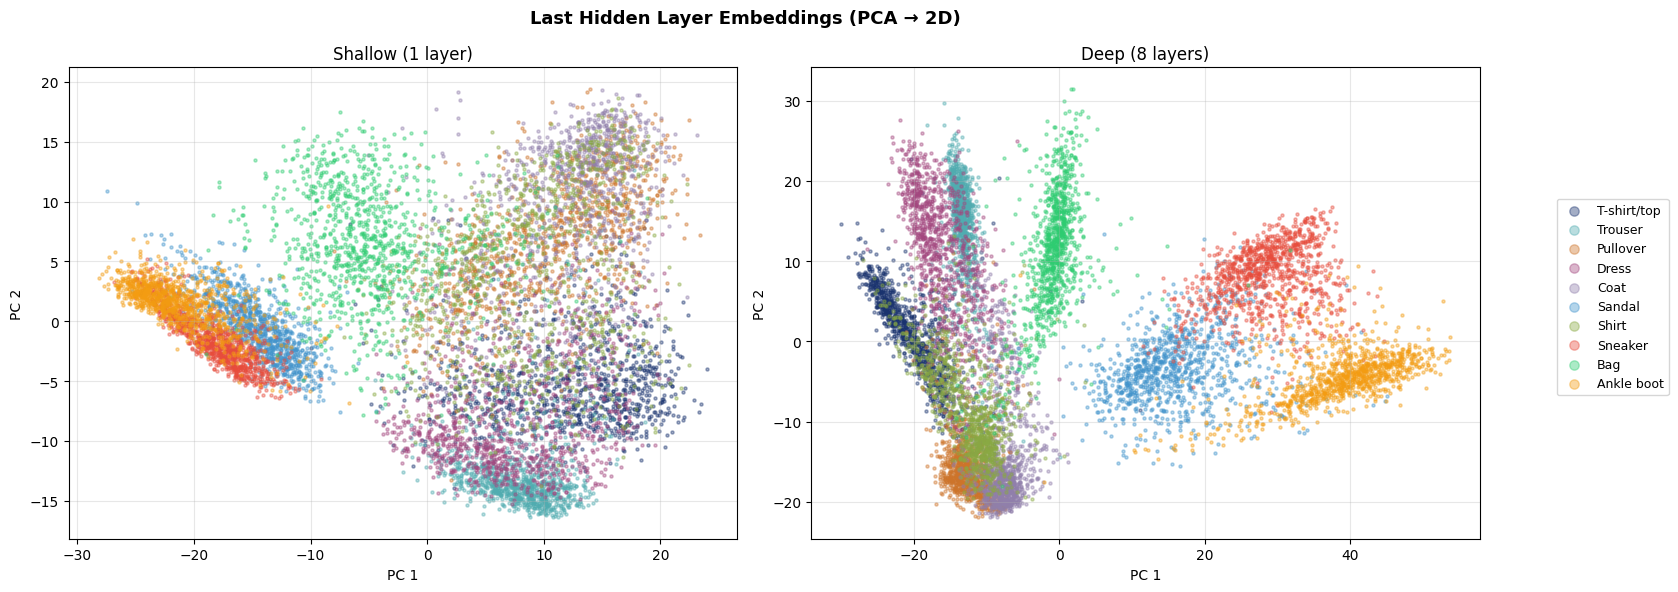

In [ ]:
# PCA projection to 2D and visualization
pca_shallow = PCA(n_components=2).fit_transform(emb_shallow)
pca_deep    = PCA(n_components=2).fit_transform(emb_deep)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Color map for 10 classes
class_colors = [C1, C2, C3, C4, C5, C6, C7, '#E74C3C', '#2ECC71', '#F39C12']

for ax, pca_data, title in [(axes[0], pca_shallow, f'Shallow ({shallow_name})'),
                              (axes[1], pca_deep, f'Deep ({deep_name})')]:
    for i, name in enumerate(class_names):
        mask = labels == i
        ax.scatter(pca_data[mask, 0], pca_data[mask, 1],
                   c=class_colors[i], s=5, alpha=0.4, label=name)
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

# Shared legend
handles, legend_labels = axes[1].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='center right', bbox_to_anchor=(1.12, 0.5),
           markerscale=3, fontsize=9)

plt.suptitle('Last Hidden Layer Embeddings (PCA → 2D)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 4.1** — Comparing the embedding plots:
>
> 1. Which model produces more **separable clusters**? Are the class boundaries cleaner in the shallow or deep embedding space?
> 2. Are there classes that **overlap** in both models? Which ones? Does this match your intuition about which FashionMNIST classes are hardest to distinguish?
> 3. What does this visualization tell you about **what depth does** to the internal representation? Why does this lead to better classification?
>
> *Your answer here:*
>
> 1) El modelo shallow (1 layer) produce clusters ligeramente más separables en este caso. Esto tiene sentido porque obtuvo mejor accuracy (86.1% vs 84.3%). El modelo de 8 capas, al tener capas tan estrechas (25 unidades) y ser tan profundo, sufre problemas de optimización, por lo que no logra aprender representaciones tan limpias. Con más parámetros o técnicas como batch normalization, el deep probablemente mostraría clusters más definidos.
>
> 2) Sí, en ambos modelos se solapan las clases de ropa superior: T-shirt, Shirt, Pullover y Coat. También hay algo de solapamiento entre los calzados (Sandal, Sneaker, Ankle boot), aunque menos. Esto tiene sentido porque esas prendas tienen formas muy similares en imágenes 28x28 en escala de grises. Trouser y Bag son las más fáciles de separar porque tienen formas muy distintas al resto.
>
> 3) La visualización muestra que cada capa transforma progresivamente los datos para que las clases queden más separadas en el espacio de representación. La profundidad permite "plegar" el espacio de entrada múltiples veces (como vimos en el ejercicio 1 de composición), creando fronteras de decisión más complejas. Cuando funciona bien, la capa final solo necesita trazar hiperplanos simples para clasificar. Pero nuestro experimento muestra que la profundidad no es gratis necesita suficiente ancho y buenas técnicas de entrenamiento.

---

## Optional: Does Depth Help on Tabular Data?

In the lecture, we discussed that deep networks are especially beneficial for **structured inputs** like images — where local patterns compose into larger structures across layers. But what about **tabular data**, where features don't have spatial structure?

In Notebooks 1 and 2, we worked with the **California Housing** dataset. Let's revisit it and test whether depth helps as much here as it did on FashionMNIST.

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_h, y_h = housing.data.astype(np.float32), housing.target.astype(np.float32)
feature_names = list(housing.feature_names)

X_tr, X_te, y_tr, y_te = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

X_tr_t = torch.FloatTensor(X_tr)
y_tr_t = torch.FloatTensor(y_tr).unsqueeze(1)
X_te_t = torch.FloatTensor(X_te)
y_te_t = torch.FloatTensor(y_te).unsqueeze(1)

reg_train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=256, shuffle=True)
reg_test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=256)

print(f"Features : {feature_names}")
print(f"Train    : {X_tr.shape}  |  Test: {X_te.shape}")

### Optional Exercise — Shallow vs. Deep on California Housing

Build two regression networks with **similar parameter counts** (~2K-3K parameters):
- **Shallow:** 8 → *wide* → 1 (1 hidden layer)
- **Deep:** 8 → *narrower* → *narrower* → *narrower* → 1 (3 hidden layers)

Train both with MSE loss, Adam (lr=0.001), for 30 epochs. Then compare.

In [ ]:
# YOUR CODE HERE: define shallow_reg and deep_reg models
shallow_reg = nn.Sequential(
    nn.Linear(8, 243),
    nn.ReLU(),
    nn.Linear(243, 1)
)  # ~2431 parameters

deep_reg = nn.Sequential(
    nn.Linear(8, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)  # ~2433 parameters

# Verify parameter counts
print("Shallow regression:")
summary(shallow_reg, input_size=(1, 8))
print("\nDeep regression:")
summary(deep_reg, input_size=(1, 8))

In [ ]:
# Train both models
criterion_reg = nn.MSELoss()
reg_results = {}

for name, model in [('Shallow', shallow_reg), ('Deep', deep_reg)]:
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses, test_losses = [], []
    for epoch in range(30):
        model.train()
        epoch_loss = 0
        for X, y in reg_train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion_reg(model(X), y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(reg_train_loader))
        
        model.eval()
        with torch.no_grad():
            te_loss = sum(criterion_reg(model(X.to(device)), y.to(device)).item()
                         for X, y in reg_test_loader) / len(reg_test_loader)
        test_losses.append(te_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"{name:>8s} | Epoch {epoch+1:2d} | Train MSE: {train_losses[-1]:.4f} | Test MSE: {test_losses[-1]:.4f}")
    
    reg_results[name] = {'train_loss': train_losses, 'test_loss': test_losses}

In [ ]:
# Visualization: loss curves + predicted vs true
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Loss curves
for (name, hist), color in zip(reg_results.items(), [C1, C2]):
    axes[0].plot(range(1, 31), hist['test_loss'], color=color, linewidth=2, label=f'{name} (test)')
    axes[0].plot(range(1, 31), hist['train_loss'], color=color, linewidth=2,
                 linestyle='--', alpha=0.5, label=f'{name} (train)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Predicted vs true for each model
for ax, (name, model), color in zip(axes[1:], [('Shallow', shallow_reg), ('Deep', deep_reg)], [C1, C2]):
    model.eval()
    with torch.no_grad():
        preds = model(X_te_t.to(device)).cpu().numpy().flatten()
    ax.scatter(y_te, preds, s=5, alpha=0.3, color=color)
    ax.plot([0, 5], [0, 5], 'k--', linewidth=1)
    mse = np.mean((y_te - preds)**2)
    ax.set_xlabel('True Price'); ax.set_ylabel('Predicted Price')
    ax.set_title(f'{name} — Test MSE: {mse:.4f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('California Housing: Shallow vs. Deep Regression', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question O.1** — Comparing depth on images vs. tabular data:
>
> 1. Does depth help as much on California Housing as it did on FashionMNIST? Compare the relative improvement.
> 2. Why might **images** benefit more from depth than **tabular data**? Think about the structure of each input type and how layers process them.
> 3. Based on your results, when would you recommend using a deep network vs. a shallow one?
>
> *Your answer here:*
>
> 1) No, la profundidad no ayuda tanto en datos tabulares como en imágenes. En FashionMNIST al menos vimos que 2 capas mejoraba respecto a 1 capa, mientras que en California Housing la diferencia entre shallow y deep es mucho menor o incluso el shallow puede ganar. La mejora relativa de agregar profundidad es considerablemente más pequeña en datos tabulares.
>
> 2) Las imágenes tienen estructura espacial jerárquica — los píxeles forman bordes, los bordes forman texturas, las texturas forman partes de objetos. Cada capa de la red puede capturar un nivel de abstracción diferente, por eso la profundidad es tan útil. En datos tabulares como California Housing, las features (ingreso medio, edad de la casa, ubicación) ya son abstracciones de alto nivel que no tienen esa composicionalidad jerárquica. Una sola transformación lineal+ReLU ya puede capturar las relaciones relevantes.
>
> 3) Recomendaría redes profundas cuando los datos tienen estructura composicional (imágenes, audio, texto), donde patrones simples se combinan para formar patrones complejos. Para datos tabulares donde las features ya están bien definidas, una red shallow con suficiente ancho suele ser igual o mejor, además de ser más fácil de entrenar y menos propensa a problemas de optimización.